# 基于K-means聚类和特征提取的手写数字识别

## 1. 预备工作

### 1.1 导入相关库

In [1]:
import numpy as np
import seaborn as sns
from collections import Counter
from scipy.spatial.transform import Rotation

import cv2
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from skimage.feature import hog

### 1.2 导入数据集

In [ ]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(np.int32)
images = X.reshape(-1, 28, 28)

### 1.3 可视化函数

In [3]:
def show(image):
    plt.figure(figsize=(8, 6))
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.show()

In [4]:
def plot_sample_images(X, y_pred, title):
    plt.figure(figsize=(10, 20))
    plt.suptitle(title, fontsize=16)
    for i in range(10):
        cluster_indices = np.where(y_pred == i)[0]
        if len(cluster_indices) == 0:
            continue
        sample_indices = np.random.choice(cluster_indices, size=5, replace=False)
        for j, idx in enumerate(sample_indices):
            plt.subplot(10, 5, i * 5 + j + 1)
            plt.imshow(X[idx].reshape(28, 28), cmap='gray')
            plt.axis('off')
            if j == 2:
                plt.title(f'Cluster {i}')
    plt.show()

In [5]:
def plot_confusion_matrix(y_pred):
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

### 1.4 多数投票重映射函数

In [6]:
def majority_voting_remap(y_pred, n_clusters=10):
    y_aligned = np.zeros_like(y_pred)
    for i in range(n_clusters):
        mask = (y_pred == i)
        if np.sum(mask) == 0:
            continue
        y_aligned[mask] = np.bincount(y[mask]).argmax()
    return y_aligned

## 2. 图像处理与特征提取

### 2.1 K-Means

准确率：0.5850428571428572


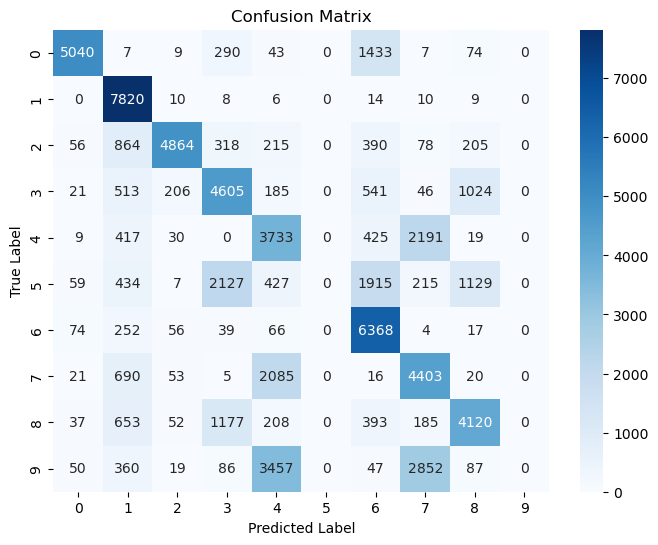

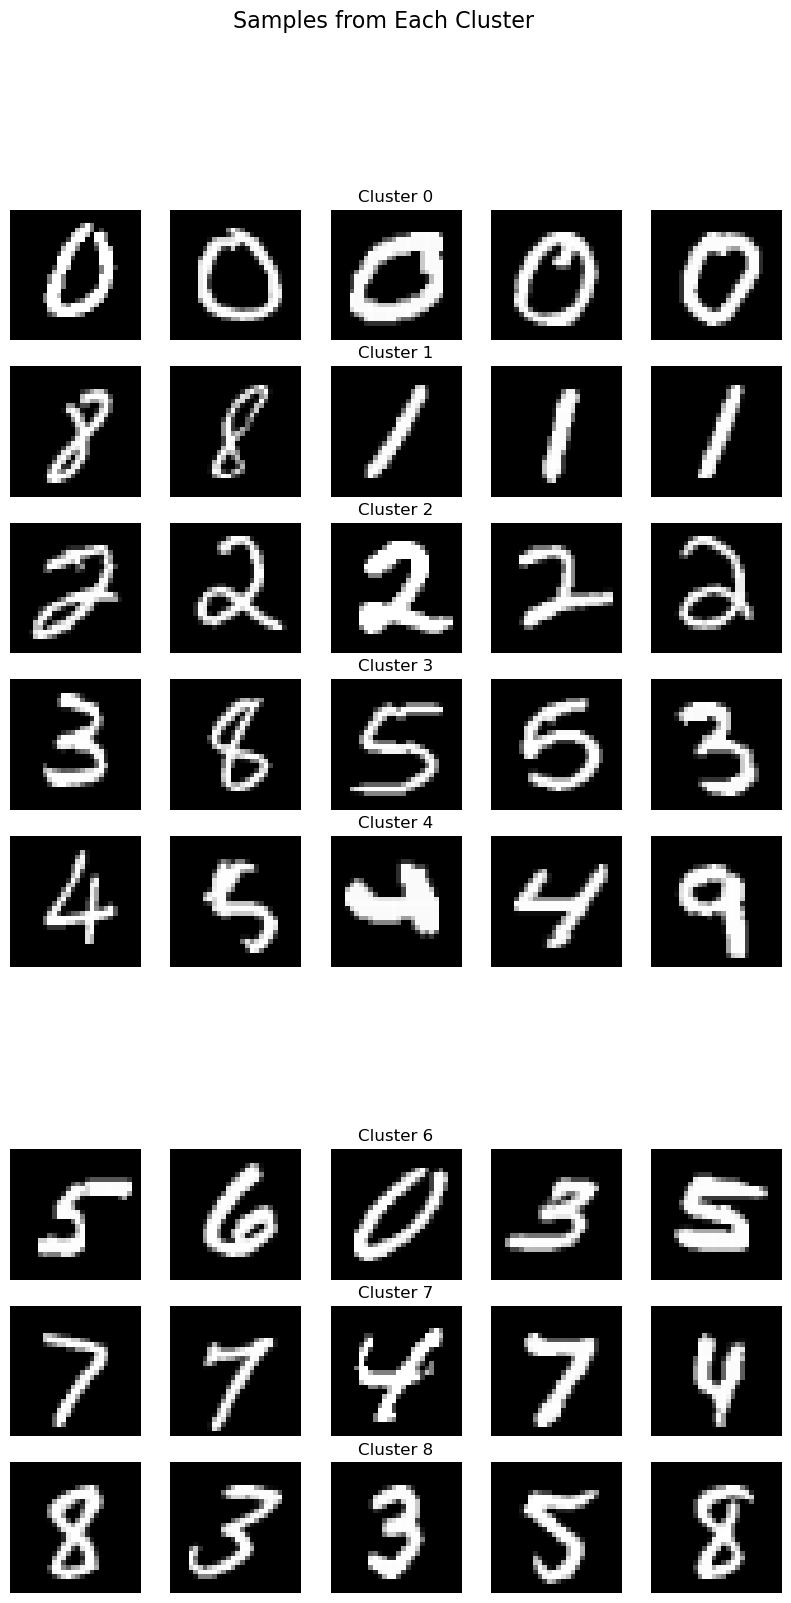

In [7]:
kmeans = KMeans(n_clusters=10, random_state=1, max_iter=1000)
y_pred = kmeans.fit_predict(X)
y_aligned = majority_voting_remap(y_pred)
print(f"准确率：{np.sum(y == y_aligned) / len(y)}")
plot_confusion_matrix(y_aligned)
plot_sample_images(X, y_aligned, "Samples from Each Cluster")

### 2.2 二值化(otsu)

In [8]:
images_binary = []
for img in images:
    _, img_binary = cv2.threshold(img.astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    images_binary.append(img_binary)
images_binary = np.array(images_binary)

准确率：0.5945857142857143


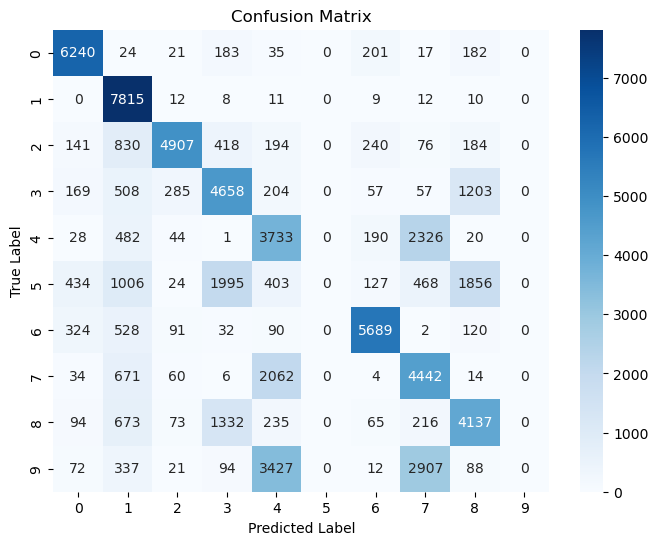

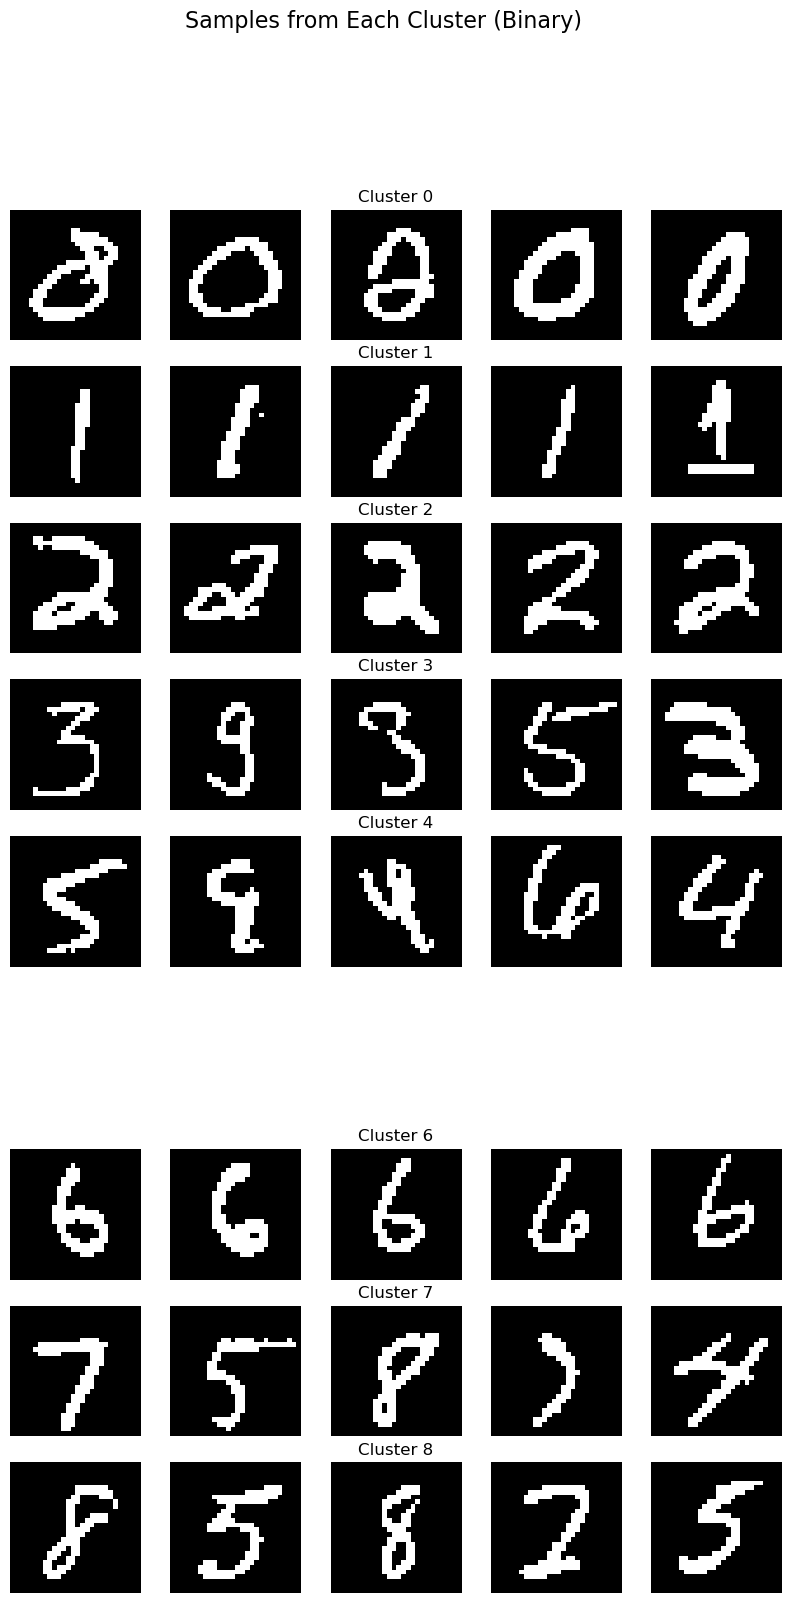

In [9]:
kmeans_binary = KMeans(n_clusters=10, random_state=1, max_iter=1000)
X_binary = images_binary.reshape(-1, 28*28)
y_pred_binary = kmeans_binary.fit_predict(X_binary)
y_aligned_binary = majority_voting_remap(y_pred_binary)
print(f"准确率：{np.sum(y == y_aligned_binary) / len(y)}")
plot_confusion_matrix(y_aligned_binary)
plot_sample_images(X_binary, y_aligned_binary, "Samples from Each Cluster (Binary)")

### 2.3 PCA旋转

In [10]:
def align_image_to_y_axis(image):
    white_pixels = np.argwhere(image)
    # 质心
    centroid = white_pixels.mean(axis=0)
    # 中心化
    centered_data = white_pixels - centroid
    # 进行PCA
    pca = PCA(n_components=2)
    pca.fit(centered_data)
    # 获取第一主成分向量
    first_pc = pca.components_[0]
    if first_pc[0] < 0:
        first_pc = -first_pc
    # 目标向量是Y轴方向 [0, 1]
    target_vector = np.array([1, 0])
    # 计算旋转角度（从第一主成分到Y轴）
    # angle = np.arccos(np.clip(np.abs(np.dot(first_pc, target_vector)), -1.0, 1.0))
    angle = np.arccos(np.clip(np.dot(first_pc, target_vector), -1.0, 1.0))
    # 确定旋转方向（使用叉积判断）
    if first_pc[0] * target_vector[1] - first_pc[1] * target_vector[0] < 0:
        angle = -angle
    # 创建旋转矩阵
    rotation_matrix = Rotation.from_rotvec([0, 0, angle]).as_matrix()[:2, :2]
    # 对图像进行旋转
    return rotate_image(image, rotation_matrix, centroid)

def rotate_image(image, rotation_matrix, center):
    """使用旋转矩阵旋转图像"""
    rows, cols = image.shape
    # 创建坐标网格
    y_coords, x_coords = np.mgrid[0:rows, 0:cols]
    # 坐标平移到原点
    centered_coords = np.stack([x_coords - center[1], y_coords - center[0]], axis=-1)
    # 应用旋转
    rotated_coords = np.dot(centered_coords, rotation_matrix.T)
    # 坐标平移回去
    final_coords = rotated_coords + np.array([center[1], center[0]])
    # 使用双线性插值进行重采样
    from scipy.ndimage import map_coordinates
    rotated_image = map_coordinates(image, [final_coords[..., 1], final_coords[..., 0]], order=1, mode='constant', cval=0, prefilter=False)
    # 二值化处理
    return rotated_image

In [11]:
images_rotate = []
for img in images_binary:
    img_rotate = align_image_to_y_axis(img)
    _, img_rotate = cv2.threshold(img_rotate.astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    images_rotate.append(img_rotate)
images_rotate = np.array(images_rotate)

准确率：0.6805285714285715


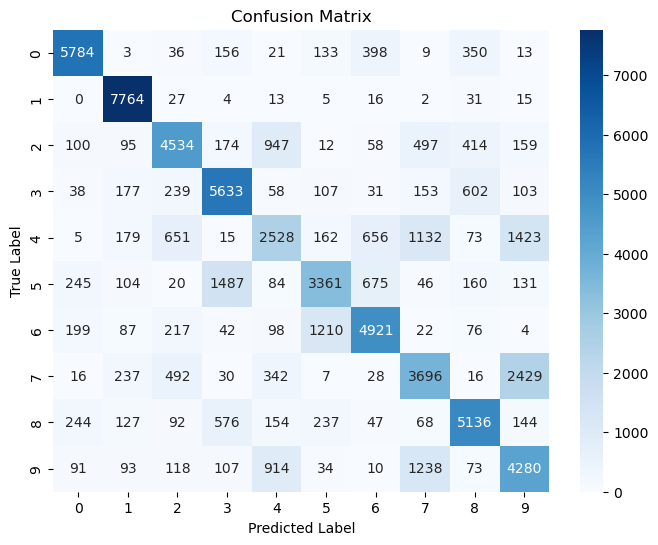

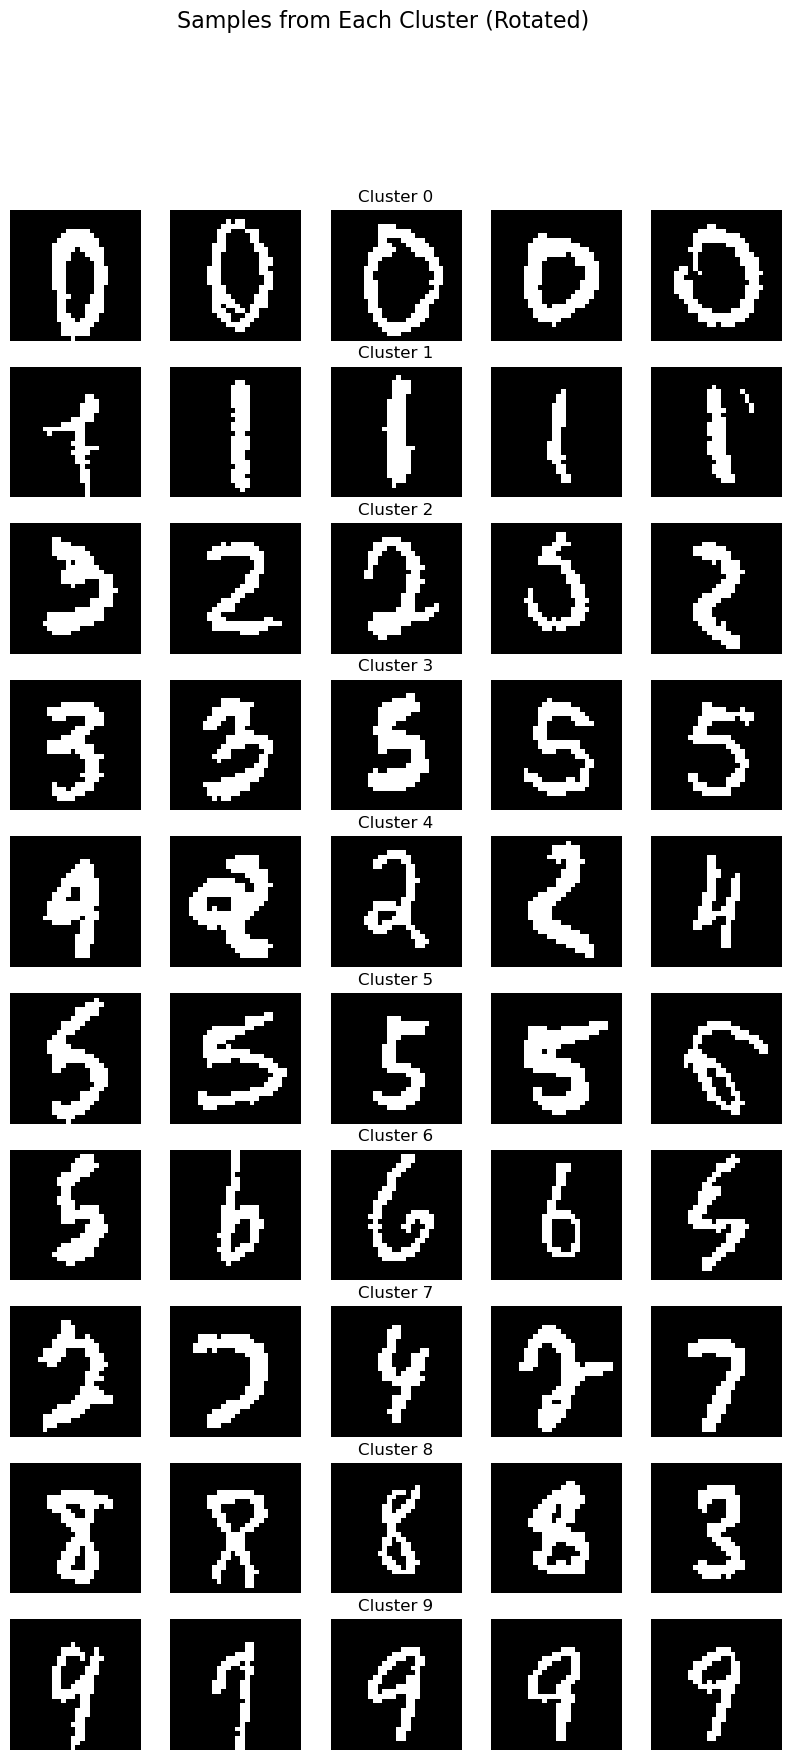

In [16]:
kmeans_rotate = KMeans(n_clusters=10, random_state=60, max_iter=1000)
X_rotate = images_rotate.reshape(-1, 28*28)
y_pred_rotate = kmeans_rotate.fit_predict(X_rotate)
y_aligned_rotate = majority_voting_remap(y_pred_rotate)
print(f"准确率：{np.sum(y == y_aligned_rotate) / len(y)}")
plot_confusion_matrix(y_aligned_rotate)
plot_sample_images(X_rotate, y_aligned_rotate, "Samples from Each Cluster (Rotated)")

### 2.4 ROI

In [17]:
def crop_and_resize_digit(img, target_size=(28, 28)):
    """
    找到图像中的数字区域，裁剪并缩放到统一尺寸。
    
    参数:
        img: 输入的灰度图 (H, W)
        target_size: 目标尺寸
    返回:
        processed_img: 处理后的图像
        rect: 原图中的外接矩形
    """
    
    # 1. 二值化
    # MNIST 原图是 0-255，255是白色背景，0是黑色笔画。
    # OpenCV findContours 需要白底黑字或黑底白字均可，但通常转为 0/1 或 0/255 方便看。
    # 为了符合常规习惯（黑底白字），我们先反转：背景变黑(0)，数字变白(255)
    # _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    
    # 2. 查找轮廓
    # RETR_EXTERNAL: 只找最外层轮廓（忽略数字内部的孔洞，如 0, 4, 6, 8, 9 内部的小圈）
    # CHAIN_APPROX_SIMPLE: 只保留轮廓的关键点，节省内存
    contours, hierarchy = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 3. 过滤噪点
    # MNIST 图像纯度很高，通常只有一个最大轮廓。但以防万一有噪点，我们选面积最大的。
    if not contours:
        return img, (0, 0, img.shape[1], img.shape[0]) # 没找到轮廓，返回原图
    
    # 找到面积最大的轮廓
    max_contour = max(contours, key=cv2.contourArea)
    
    # 4. 获取最小外接矩形
    # rect = (x, y, w, h)
    x, y, w, h = cv2.boundingRect(max_contour)
    
    # 5. 裁剪区域
    # 注意：要在原图 img 上裁剪，不要在 binary 上裁剪（除非你想要纯黑白边缘）
    # 加一点 padding 以防贴边太紧
    padding = 2
    x_start = max(0, x - padding)
    y_start = max(0, y - padding)
    x_end = min(img.shape[1], x + w + padding)
    y_end = min(img.shape[0], y + h + padding)
    
    digit_roi = img[y_start:y_end, x_start:x_end]
    
    # 6. 缩放到目标尺寸
    # 使用 INTER_AREA 缩小效果最好，INTER_LINEAR 放大效果较好。这里是缩放+放大混合，用线性即可。
    resized_digit = cv2.resize(digit_roi, target_size, interpolation=cv2.INTER_LINEAR)
    
    return resized_digit

In [18]:
images_roi = []
for img in images_rotate:
    img_roi = crop_and_resize_digit(img)
    _, img_roi = cv2.threshold(img_roi.astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    images_roi.append(img_roi)
images_roi = np.array(images_roi)

准确率：0.6512571428571429


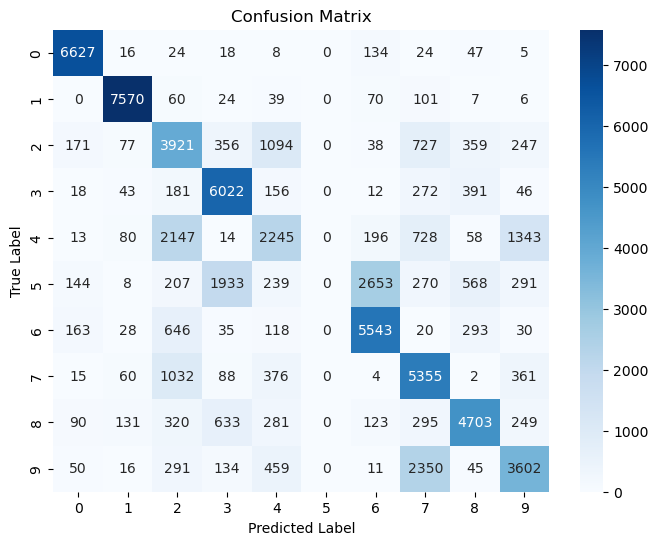

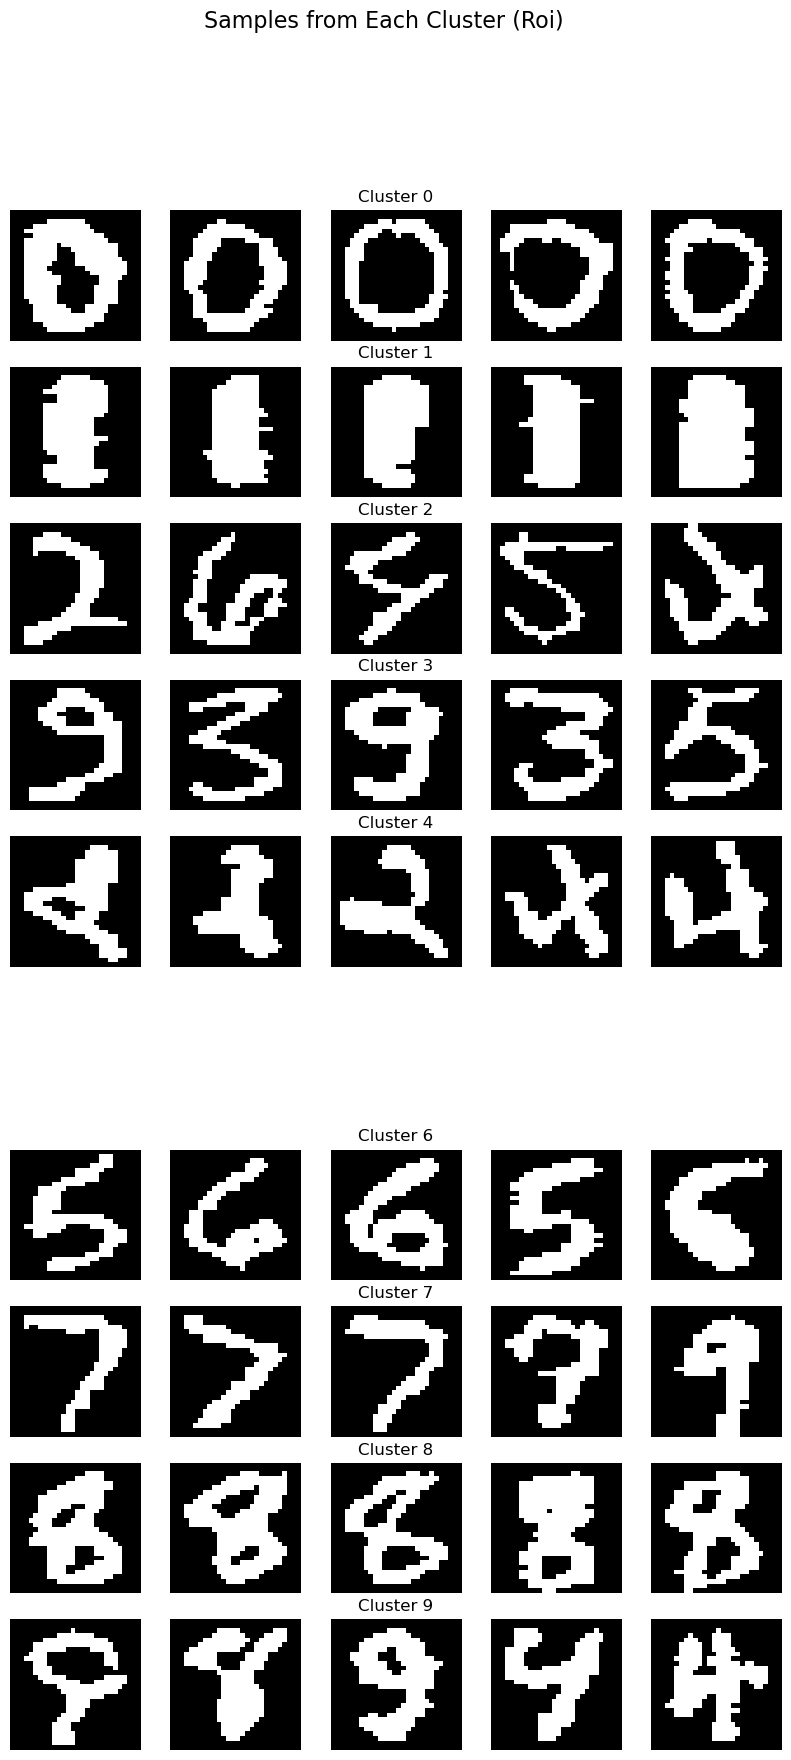

In [19]:
kmeans_roi = KMeans(n_clusters=10, random_state=1, max_iter=1000)
X_roi = images_roi.reshape(-1, 28*28)
y_pred_roi = kmeans_roi.fit_predict(X_roi)
y_aligned_roi = majority_voting_remap(y_pred_roi)
print(f"准确率：{np.sum(y == y_aligned_roi) / len(y)}")
plot_confusion_matrix(y_aligned_roi)
plot_sample_images(X_roi, y_aligned_roi, "Samples from Each Cluster (Roi)")

### 2.5 HOG

In [20]:
images_hog = []
for img in images_binary:
    img_hog = hog(img, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2), transform_sqrt=True)
    images_hog.append(img_hog)
images_hog = np.array(images_hog)

准确率：0.7261571428571428


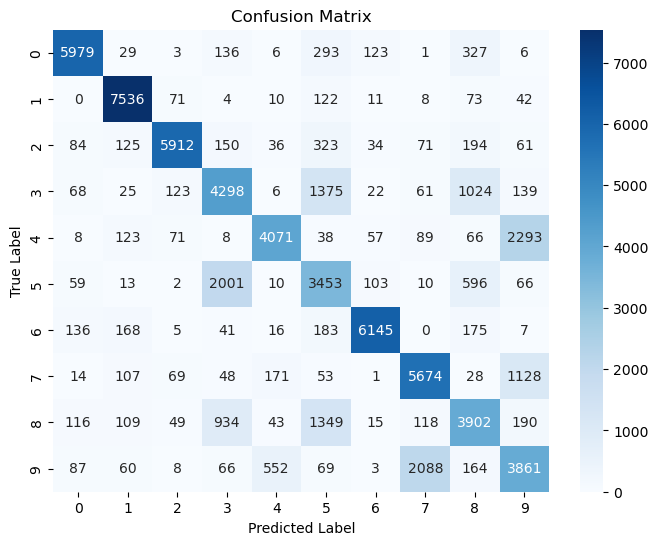

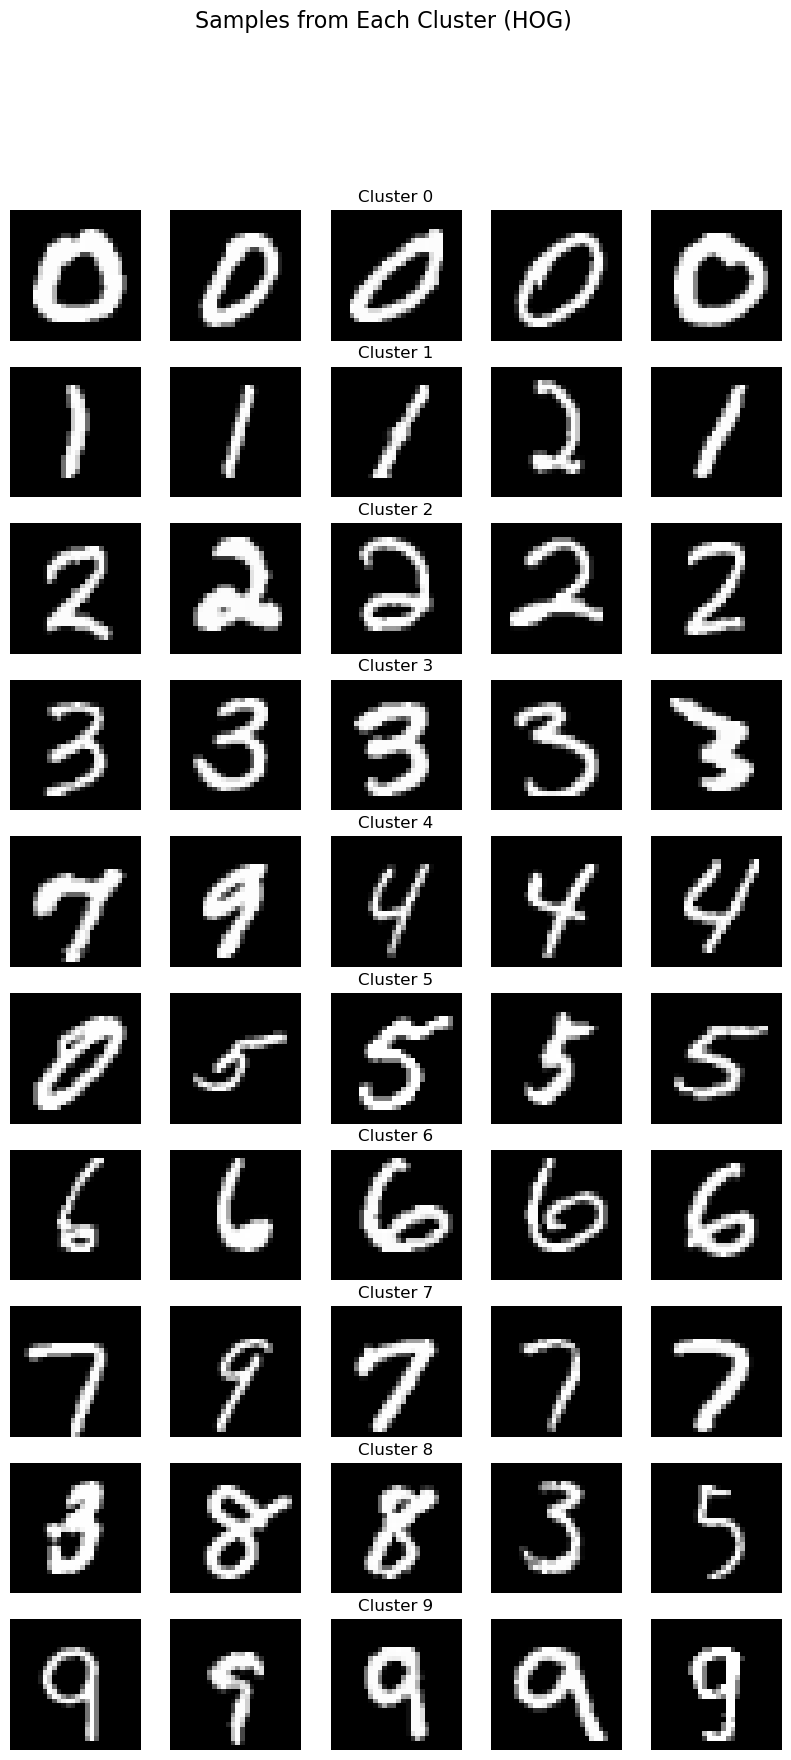

In [22]:
kmeans_hog = KMeans(n_clusters=10, random_state=600, max_iter=1000)
X_hog = images_hog
y_pred_hog = kmeans_hog.fit_predict(X_hog)
y_aligned_hog = np.zeros_like(y_pred_hog)
y_aligned_hog = majority_voting_remap(y_pred_hog)
print(f"准确率：{np.sum(y == y_aligned_hog) / len(y)}")
plot_confusion_matrix(y_aligned_hog)
plot_sample_images(X, y_aligned_hog, "Samples from Each Cluster (HOG)")

## 3. 增加聚类数

In [23]:
print(np.bincount(y_pred))
print(sum(y_pred))

[ 9991  6720 10425  8655  5121  5367  6421  5290  6704  5306]
277796


准确率：0.8771


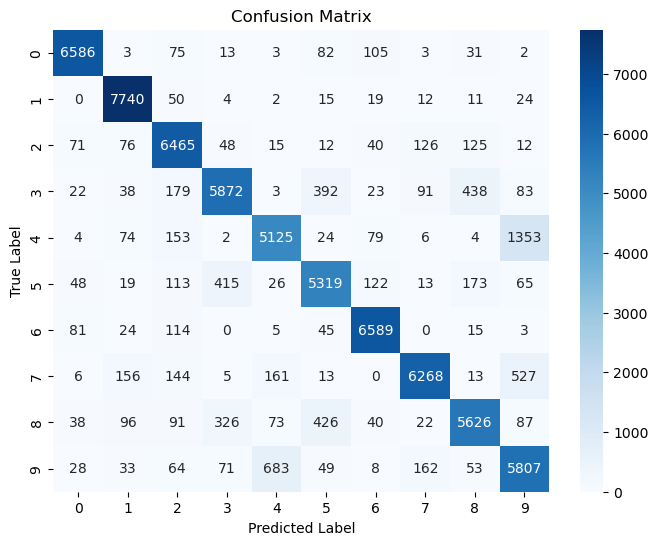

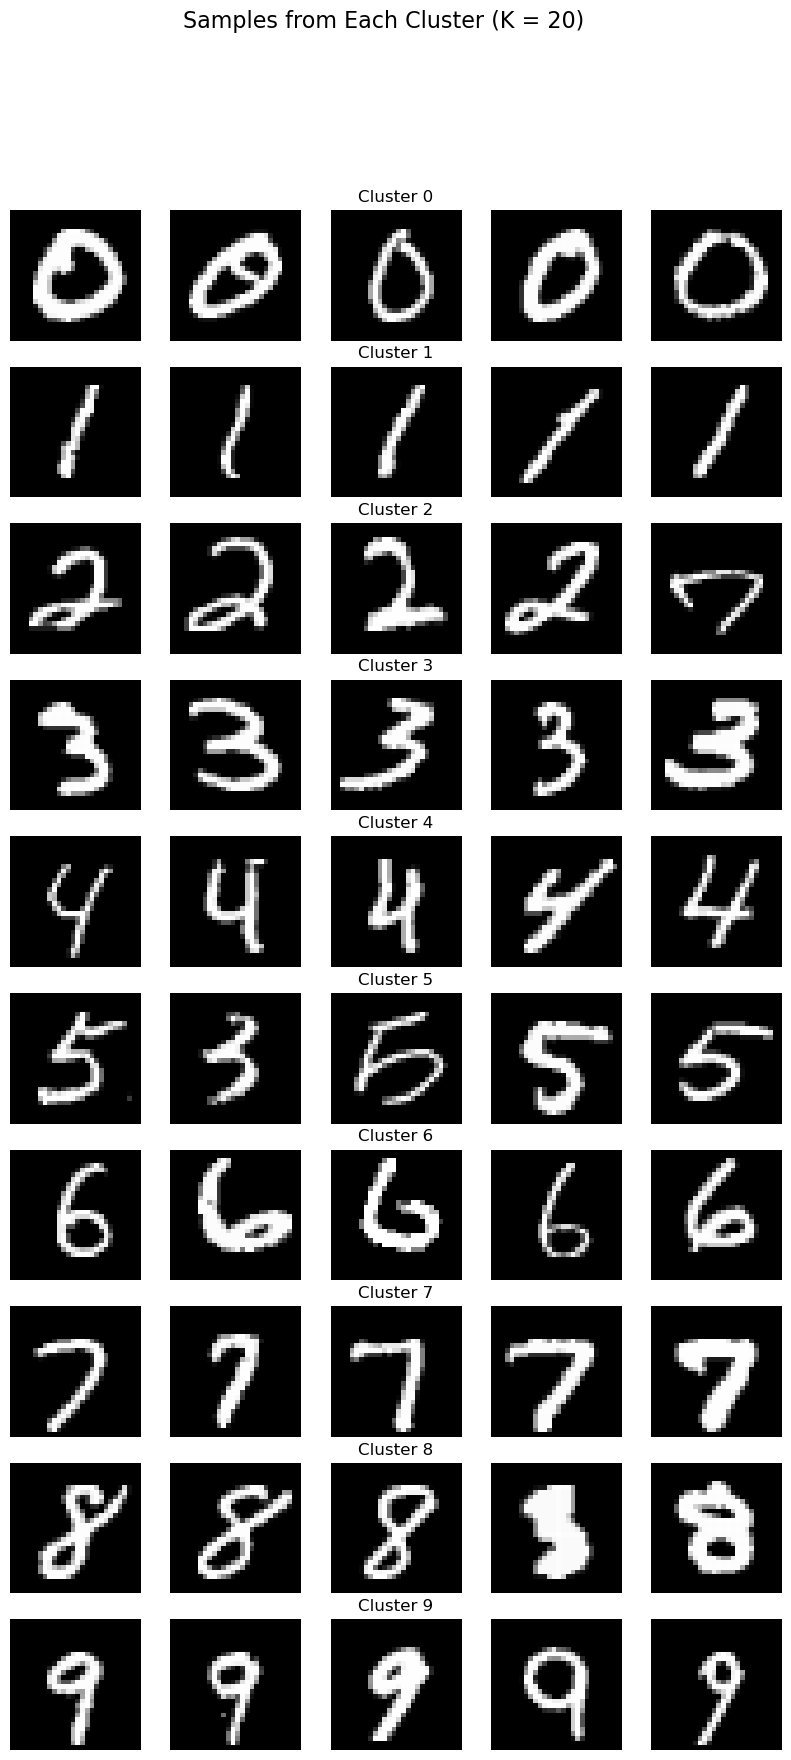

In [24]:
kmeans = KMeans(n_clusters=100, random_state=1, max_iter=1000)
y_pred = kmeans.fit_predict(X)
y_aligned = majority_voting_remap(y_pred, 100)
print(f"准确率：{np.sum(y == y_aligned) / len(y)}")
plot_confusion_matrix(y_aligned)
plot_sample_images(X, y_aligned, "Samples from Each Cluster (K = 20)")

准确率：0.9205


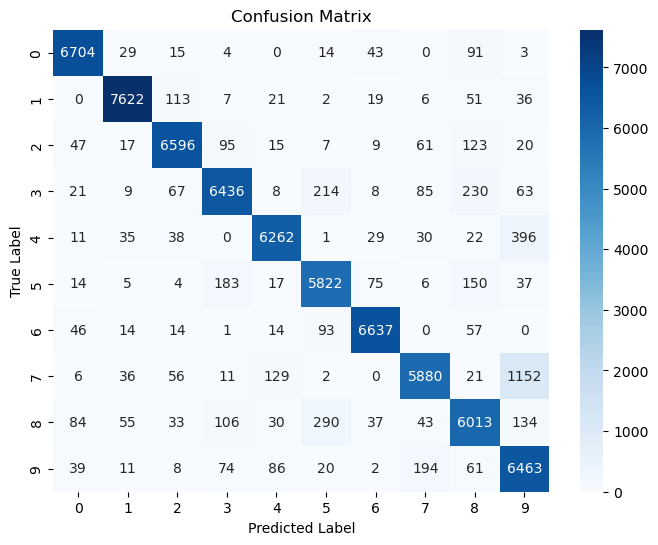

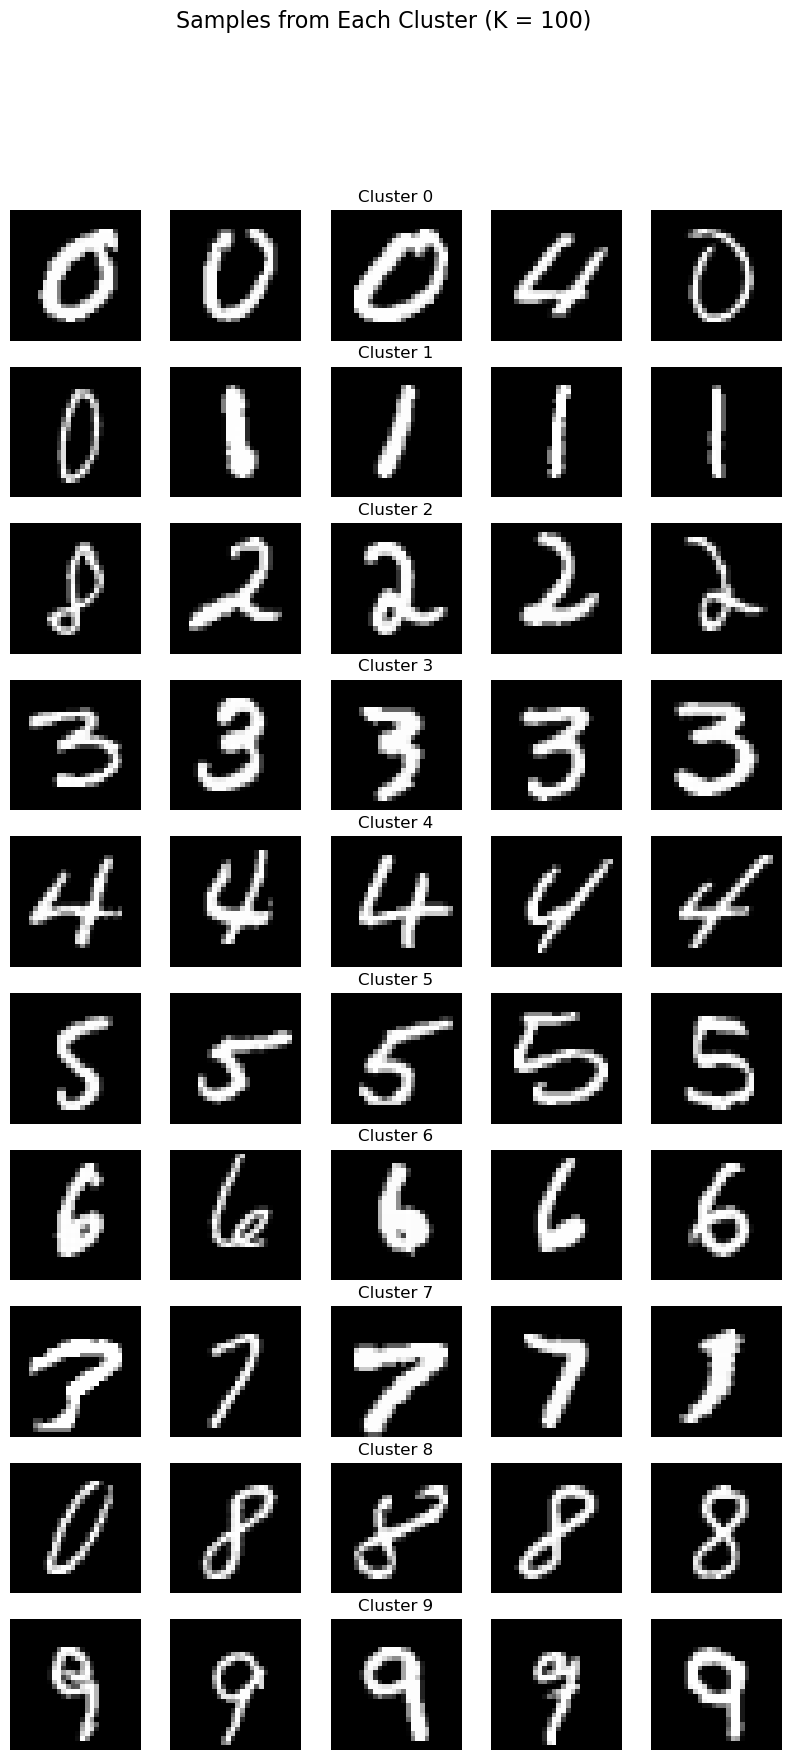

In [32]:
kmeans_hog = KMeans(n_clusters=100, random_state=42, max_iter=1000)
y_pred = kmeans_hog.fit_predict(X_hog)
y_aligned = majority_voting_remap(y_pred, 100)
print(f"准确率：{np.sum(y == y_aligned) / len(y)}")
plot_confusion_matrix(y_aligned)
plot_sample_images(X, y_aligned, "Samples from Each Cluster (K = 100)")